### CVS file loaded to pythom and  ready to clean the column names so they are safe for MySQL and easier to work with in Python

## Step 1: Load Raw Data and Create Working DataFrame

Before performing any cleaning, we first load the raw CSV into Python.  
The raw data may contain:

- Unnecessary columns
- Special characters in column names
- Irrelevant or redundant data

To safely perform cleaning, we create a **working DataFrame** called `df_clean` that:

- Selects only the columns relevant for our analysis and forecasting
- Standardizes column names to be Python/MySQL friendly
- Preserves the original CSV untouched for reproducibility


In [1]:
import pandas as pd
df = pd.read_csv("../data/electricity_region_2005_2024.csv")
df.head()


,Year,Code,Region,Standard_domestic_meters_thousands,E7_domestic_meters_thousands,Domestic_meters_thouasands,Non_domestic_meters_thousands,All_meters_thousands,Standard_domestic_consumption_GWh,E7_domestic_consumption_GWh,...,E7_domestic_mean_consumption_KWh_per_meter,Domestic_mean_consumption_KWh_per_meter,Non_domestic_mean_consumption_KWh_per_meter,All_mean_consumption_kWh_per_meter,Standard_domestic_median_consumption_kWh_per_meter,E7_domestic_median_consumption_kWh_per_meter,Domestic_median_consumption_kWh_per_meter,Non_domestic_median_consumption_kWh_per_meter,All_median_consumption_kWh_per_meter,Domestic_mean_consumption_kWh_per_household
0,2005,K03000001,Great Britain,NaN,NaN,25948.940,2446.010,28394.950,NaN,NaN,...,NaN,4602.303766,82129.45427,11280.68092,NaN,NaN,NaN,NaN,NaN,NaN
1,2005,E92000001,England,NaN,NaN,21929.970,2069.524,23999.494,NaN,NaN,...,NaN,4617.764666,80540.96494,11164.77291,NaN,NaN,NaN,NaN,NaN,NaN
2,2005,E12000001,North East,NaN,NaN,1170.117,82.182,1252.299,NaN,NaN,...,NaN,3887.010366,113756.82640,11097.20635,NaN,NaN,NaN,NaN,NaN,NaN
3,2005,E12000002,North West,NaN,NaN,2910.574,236.806,3147.380,NaN,NaN,...,NaN,4527.388316,97610.39639,11530.86893,NaN,NaN,NaN,NaN,NaN,NaN
4,2005,E12000003,Yorkshire and The Humber,NaN,NaN,2269.004,181.093,2450.097,NaN,NaN,...,NaN,4320.640484,94051.51298,10952.88112,NaN,NaN,NaN,NaN,NaN,NaN


## Some of the column names have:

- Spaces

- Special characters

- Long names

I’ll replace all non-alphanumeric characters with _ and strip extra spaces.

In [2]:
# Clean column names for MySQL / Python
df.columns = df.columns.str.replace('[^0-9a-zA-Z_]', '_', regex=True)
df.columns = df.columns.str.strip()
df.head()


,Year,Code,Region,Standard_domestic_meters_thousands,E7_domestic_meters_thousands,Domestic_meters_thouasands,Non_domestic_meters_thousands,All_meters_thousands,Standard_domestic_consumption_GWh,E7_domestic_consumption_GWh,...,E7_domestic_mean_consumption_KWh_per_meter,Domestic_mean_consumption_KWh_per_meter,Non_domestic_mean_consumption_KWh_per_meter,All_mean_consumption_kWh_per_meter,Standard_domestic_median_consumption_kWh_per_meter,E7_domestic_median_consumption_kWh_per_meter,Domestic_median_consumption_kWh_per_meter,Non_domestic_median_consumption_kWh_per_meter,All_median_consumption_kWh_per_meter,Domestic_mean_consumption_kWh_per_household
0,2005,K03000001,Great Britain,NaN,NaN,25948.940,2446.010,28394.950,NaN,NaN,...,NaN,4602.303766,82129.45427,11280.68092,NaN,NaN,NaN,NaN,NaN,NaN
1,2005,E92000001,England,NaN,NaN,21929.970,2069.524,23999.494,NaN,NaN,...,NaN,4617.764666,80540.96494,11164.77291,NaN,NaN,NaN,NaN,NaN,NaN
2,2005,E12000001,North East,NaN,NaN,1170.117,82.182,1252.299,NaN,NaN,...,NaN,3887.010366,113756.82640,11097.20635,NaN,NaN,NaN,NaN,NaN,NaN
3,2005,E12000002,North West,NaN,NaN,2910.574,236.806,3147.380,NaN,NaN,...,NaN,4527.388316,97610.39639,11530.86893,NaN,NaN,NaN,NaN,NaN,NaN
4,2005,E12000003,Yorkshire and The Humber,NaN,NaN,2269.004,181.093,2450.097,NaN,NaN,...,NaN,4320.640484,94051.51298,10952.88112,NaN,NaN,NaN,NaN,NaN,NaN


[^0-9a-zA-Z_] → replaces everything except letters, numbers, and underscore

.strip() → removes extra spaces

After running this, the column names look like:

- Year

- Code

- Region

- Standard_domestic_meters_thousands

- E7_domestic_meters_thousands

- Domestic_meters_thouasands

- Non_domestic_meters_thousands

- All_meters_thousands

### For my first forecast, I can simplify and only keep:

- Year → time variable

- Region → region

- All_meters_thousands → number of meters

- All_mean_consumption_kWh_per_meter → consumption

In [ ]:
##  Load Raw Data and Create Working DataFrame

Before performing any cleaning, we first load the raw CSV into Python.  
The raw data may contain:

- Unnecessary columns
- Special characters in column names
- Irrelevant or redundant data

To safely perform cleaning, we create a **working DataFrame** called `df_clean` that:

- Selects only the columns relevant for our analysis and forecasting
- Standardizes column names to be Python/MySQL friendly
- Preserves the original CSV untouched for reproducibility


## Create df_clean and then clean the data. I have selected just the columns I think are neccessary for my analysis 

In [7]:
import pandas as pd
import numpy as np

# -----------------------------
# Step 1: Load raw CSV
# -----------------------------
df = pd.read_csv("../data/electricity_region_2005_2024.csv")

# -----------------------------
# Step 2: Clean column names
# -----------------------------
df.columns = df.columns.str.replace('[^0-9a-zA-Z_]', '_', regex=True)
df.columns = df.columns.str.strip()

# -----------------------------
# Step 3: List all columns (for reference)
# -----------------------------
print("Columns in CSV:")
print(df.columns.tolist())

# -----------------------------
# Step 4: Select relevant columns
# -----------------------------
df_clean = df[['Year', 'Region', 'All_meters_thousands', 'All_mean_consumption_kWh_per_meter']].copy()
df_clean.columns = ['year', 'region', 'all_meters', 'all_mean_kwh_per_meter']

# -----------------------------
# Step 5: Remove duplicates
# -----------------------------
df_clean = df_clean.drop_duplicates()

# -----------------------------
# Step 6: Handle missing values
# -----------------------------
# Fill missing meters with 0
df_clean['all_meters'] = df_clean['all_meters'].fillna(0)

# Fill missing consumption with median per region
df_clean['all_mean_kwh_per_meter'] = df_clean.groupby('region')['all_mean_kwh_per_meter'] \
                                             .transform(lambda x: x.fillna(x.median()))

# -----------------------------
# Step 7: Standardize data types
# -----------------------------
df_clean['year'] = df_clean['year'].astype(int)
df_clean['region'] = df_clean['region'].astype(str)
df_clean['all_meters'] = df_clean['all_meters'].astype(float)
df_clean['all_mean_kwh_per_meter'] = df_clean['all_mean_kwh_per_meter'].astype(float)

# -----------------------------
# Step 8: Fix structural errors
# -----------------------------
df_clean['region'] = df_clean['region'].str.strip().str.title()  # remove extra spaces & capitalize

# -----------------------------
# Step 9: Filter out outliers
# -----------------------------
# Using z-score for consumption
df_clean['zscore'] = (df_clean['all_mean_kwh_per_meter'] - df_clean['all_mean_kwh_per_meter'].mean()) / df_clean['all_mean_kwh_per_meter'].std()
df_clean = df_clean[df_clean['zscore'].abs() <= 3]  # keep only -3 <= z <= 3
df_clean = df_clean.drop(columns=['zscore'])

# -----------------------------
# Step 10: Format numbers for display
# -----------------------------
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)

# Optional: sort by year and region
df_clean = df_clean.sort_values(by=['year', 'region']).reset_index(drop=True)

# Round numbers
df_clean['all_meters'] = df_clean['all_meters'].round(2)
df_clean['all_mean_kwh_per_meter'] = df_clean['all_mean_kwh_per_meter'].round(2)

# -----------------------------
# Step 11: Preview clean dataset
# -----------------------------
df_clean.head()


Columns in CSV:
['Year', 'Code', 'Region', 'Standard_domestic_meters_thousands', 'E7_domestic_meters_thousands', 'Domestic_meters_thouasands', 'Non_domestic_meters_thousands', 'All_meters_thousands', 'Standard_domestic_consumption_GWh', 'E7_domestic_consumption_GWh', 'Domestic_consumption_GWh', 'Non_domestic_consumption_GWh', 'All_consumption_GWh', 'Standard_domestic_mean_consumption_KWh', 'E7_domestic_mean_consumption_KWh_per_meter', 'Domestic_mean_consumption_KWh_per_meter', 'Non_domestic_mean_consumption_KWh_per_meter', 'All_mean_consumption_kWh_per_meter', 'Standard_domestic_median_consumption_kWh_per_meter', 'E7_domestic_median_consumption_kWh_per_meter', 'Domestic_median_consumption_kWh_per_meter', 'Non_domestic_median_consumption_kWh_per_meter', 'All_median_consumption_kWh_per_meter', 'Domestic_mean_consumption_kWh_per_household']


,year,region,all_meters,all_mean_kwh_per_meter
0,2005,East,"2,658.17","11,012.50"
1,2005,East Midlands,"2,072.78","11,548.88"
2,2005,England,"23,999.49","11,164.77"
3,2005,Great Britain,"28,394.95","11,280.68"
4,2005,London,"3,669.67","11,291.16"


### Install python MySQL connector

In [8]:
pip install mysql-connector-python


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Connect to MySQL from Python

In [9]:
import mysql.connector

# Connect to MySQL without password
conn = mysql.connector.connect(
    host="localhost",
    user="root",        # your MySQL username
    password="",        # no password
    database="uk_energy"
)

cursor = conn.cursor()
print("Connected to MySQL successfully!")


Connected to MySQL successfully!


### Create MySQL table

In [10]:
# Create table to store clean energy data
cursor.execute("""
CREATE TABLE IF NOT EXISTS electricity_forecast (
    year INT,
    region VARCHAR(100),
    all_meters DECIMAL(12,2),
    all_mean_kwh_per_meter DECIMAL(12,2)
);
""")
conn.commit()
print("Table created successfully!")


Table created successfully!


### Insert clean data into MySQL

In [11]:
# Insert rows from df_clean
for i, row in df_clean.iterrows():
    sql = "INSERT INTO electricity_forecast (year, region, all_meters, all_mean_kwh_per_meter) VALUES (%s, %s, %s, %s)"
    cursor.execute(sql, tuple(row))

conn.commit()
conn.close()
print("Data inserted successfully into MySQL!")


Data inserted successfully into MySQL!


### Create electricity_forecast table in MySQL

In [14]:
import mysql.connector

# Step 1: Connect to MySQL server (no database yet)
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=""   # no password
)

cursor = conn.cursor()
print("Connected to MySQL server successfully!")

# Step 2: Create the database if it doesn't exist
cursor.execute("CREATE DATABASE IF NOT EXISTS uk_energy;")
print("Database 'uk_energy' is ready!")

# Step 3: Switch to the database
cursor.execute("USE uk_energy;")
print("Using database 'uk_energy'")

# Step 4: Create the table
cursor.execute("""
CREATE TABLE IF NOT EXISTS electricity_forecast (
    year INT,
    region VARCHAR(100),
    all_meters DECIMAL(12,2),
    all_mean_kwh_per_meter DECIMAL(12,2)
);
""")
conn.commit()
print("Table 'electricity_forecast' created successfully!")

# Step 5: Close connection
conn.close()
print("MySQL connection closed.")


Connected to MySQL server successfully!
Database 'uk_energy' is ready!
Using database 'uk_energy'
Table 'electricity_forecast' created successfully!
MySQL connection closed.


### Insert clean data into MySQL

In [15]:
import mysql.connector

# Connect to MySQL and use the database
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=""   # no password
)

cursor = conn.cursor()

# Select the database
cursor.execute("USE uk_energy;")

# Insert rows from df_clean
for i, row in df_clean.iterrows():
    sql = "INSERT INTO electricity_forecast (year, region, all_meters, all_mean_kwh_per_meter) VALUES (%s, %s, %s, %s)"
    cursor.execute(sql, tuple(row))

# Commit changes
conn.commit()
print("Data inserted successfully into MySQL!")

# Close connection
conn.close()
print("MySQL connection closed.")


Data inserted successfully into MySQL!
MySQL connection closed.


## Prophet for forecasting UK electricity consumption by region.

#### Step 1: Install Prophet

In [21]:
!pip install sqlalchemy pymysql




  Using cached pymysql-1.1.2-py3-none-any.whl (45 kB)



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**- Why:** Prophet is easy to use for time series forecasting and handles trends and seasonality automatically.

- Great for a professional ETL → Forecast → Dashboard pipeline.

#### Step 2: Load Clean Data from MySQL


- I will now fetch the data I inserted into MySQL.

In [22]:
import pandas as pd
import mysql.connector

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",  # no password
    database="uk_energy"
)

# Load data into a DataFrame
query = "SELECT year, region, all_mean_kwh_per_meter FROM electricity_forecast;"
df_forecast = pd.read_sql(query, conn)

# Close connection
conn.close()

# Quick preview
df_forecast.head()


C:\Users\ASUS-PC\AppData\Local\Temp\ipykernel_16528\1204615169.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_forecast = pd.read_sql(query, conn)


,year,region,all_mean_kwh_per_meter
0,2005,East,"11,012.50"
1,2005,East Midlands,"11,548.88"
2,2005,England,"11,164.77"
3,2005,Great Britain,"11,280.68"
4,2005,London,"11,291.16"


## Explanation:

- I am querying the electricity_forecast table from MySQL.

- all_mean_kwh_per_meter is the target variable we want to forecast.

- Closing the connection after reading is a best practice.

## Step 3: Prepare data for Prophet

#### Prophet expects two columns:

- ds → date/time (I’ll use year)

- y → numeric value to forecast

- I will also forecast for each region separately.

In [18]:
# Prepare data for Prophet for one region (example: "England")
region_name = "England"
df_region = df_forecast[df_forecast['region'] == region_name].copy()

# Prophet needs 'ds' and 'y'
df_region = df_region.rename(columns={
    'year': 'ds',
    'all_mean_kwh_per_meter': 'y'
})

# Convert 'ds' to datetime
df_region['ds'] = pd.to_datetime(df_region['ds'], format='%Y')
df_region.head()


,ds,region,y
2,2005-01-01,England,"11,164.77"
15,2006-01-01,England,"10,973.21"
29,2007-01-01,England,"10,584.35"
43,2008-01-01,England,"10,359.86"
57,2009-01-01,England,"9,927.25"


#### Explanation:

- I filter for one region first (I can loop later).

- Rename columns for Prophet: ds and y.

- Convert ds to datetime so Prophet knows it’s a time series.

## Step 4: Fit the prophet model

In [19]:
from prophet import Prophet

# Initialize the model
model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)

# Fit the model
model.fit(df_region)


C:\Users\ASUS-PC\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
20:49:29 - cmdstanpy - INFO - Chain [1] start processing
20:49:33 - cmdstanpy - INFO - Chain [1] done processing


## Step 5: Make future predictions

In [23]:
# Create future dataframe for next 5 years
future = model.make_future_dataframe(periods=5, freq='Y')  # 5 years

# Predict
forecast = model.predict(future)

# Preview forecast
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()


C:\Users\ASUS-PC\AppData\Local\Programs\Python\Python310\lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
20,2024-12-31,"7,350.43","7,229.43","7,480.21"
21,2025-12-31,"7,028.01","6,898.66","7,154.23"
22,2026-12-31,"6,663.06","6,510.51","6,816.66"
23,2027-12-31,"6,255.94","6,080.57","6,436.39"
24,2028-12-31,"6,589.32","6,353.58","6,818.75"


#### Explanation:

- make_future_dataframe(periods=5, freq='Y') → forecast next 5 years.

- yhat → predicted value

- yhat_lower and yhat_upper → confidence intervals

## Step 6: Visualize forecast

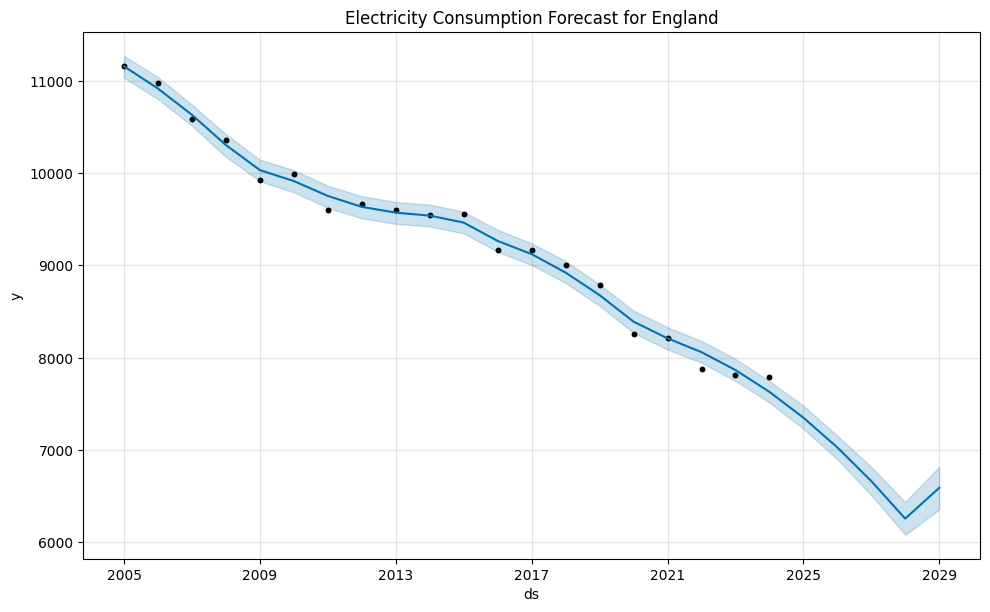

In [24]:
from prophet.plot import plot_plotly
import matplotlib.pyplot as plt

# Prophet built-in plot
fig1 = model.plot(forecast)
plt.title(f"Electricity Consumption Forecast for {region_name}")
plt.show()


## Explanation:

- Shows past data and forecast with confidence intervals

## Step 7: Forecast all regions

In [26]:
# -----------------------------
# I saw a lot of earings, I now want to hide warnings
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import mysql.connector
from prophet import Prophet

# -----------------------------
# Load data from MySQL
# -----------------------------
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="uk_energy"
)

query = """
SELECT year, region, all_mean_kwh_per_meter
FROM electricity_forecast;
"""

df = pd.read_sql(query, conn)
conn.close()

print("Data loaded successfully!")

# -----------------------------
# Prepare regions
# -----------------------------
regions = df['region'].unique()

# Store forecasts here
all_forecasts = []

# -----------------------------
# Forecast for each region
# -----------------------------
for region in regions:
    
    # Filter region
    df_r = df[df['region'] == region].copy()
    
    # Rename for Prophet
    df_r = df_r.rename(columns={
        'year': 'ds',
        'all_mean_kwh_per_meter': 'y'
    })
    
    # Convert year to datetime
    df_r['ds'] = pd.to_datetime(df_r['ds'], format='%Y')
    
    # Create model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    
    # Train model
    model.fit(df_r)
    
    # Create future dates (5 years)
    future = model.make_future_dataframe(
        periods=5,
        freq='YE'   # Year-End (no warning)
    )
    
    # Predict
    forecast = model.predict(future)
    
    # Keep important columns
    forecast_result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    
    # Add region column
    forecast_result['region'] = region
    
    # Store
    all_forecasts.append(forecast_result)

# -----------------------------
# Combine all regions
# -----------------------------
final_forecast = pd.concat(all_forecasts, ignore_index=True)

print("Forecasting completed!")

# -----------------------------
# Format output
# -----------------------------
final_forecast['year'] = final_forecast['ds'].dt.year

final_forecast = final_forecast[['year', 'region', 'yhat', 'yhat_lower', 'yhat_upper']]

final_forecast = final_forecast.round(2)

# -----------------------------
# Preview
# -----------------------------
final_forecast.head()


Data loaded successfully!


21:18:30 - cmdstanpy - INFO - Chain [1] start processing
21:18:33 - cmdstanpy - INFO - Chain [1] done processing
21:18:34 - cmdstanpy - INFO - Chain [1] start processing
21:18:36 - cmdstanpy - INFO - Chain [1] done processing
21:18:37 - cmdstanpy - INFO - Chain [1] start processing
21:18:39 - cmdstanpy - INFO - Chain [1] done processing
21:18:39 - cmdstanpy - INFO - Chain [1] start processing
21:18:41 - cmdstanpy - INFO - Chain [1] done processing
21:18:42 - cmdstanpy - INFO - Chain [1] start processing
21:18:44 - cmdstanpy - INFO - Chain [1] done processing
21:18:45 - cmdstanpy - INFO - Chain [1] start processing
21:18:47 - cmdstanpy - INFO - Chain [1] done processing
21:18:48 - cmdstanpy - INFO - Chain [1] start processing
21:18:50 - cmdstanpy - INFO - Chain [1] done processing
21:18:50 - cmdstanpy - INFO - Chain [1] start processing
21:18:52 - cmdstanpy - INFO - Chain [1] done processing
21:18:52 - cmdstanpy - INFO - Chain [1] start processing
21:18:54 - cmdstanpy - INFO - Chain [1]

Forecasting completed!


,year,region,yhat,yhat_lower,yhat_upper
0,2005,East,"10,991.93","10,863.90","11,112.78"
1,2006,East,"10,725.61","10,602.03","10,848.70"
2,2007,East,"10,456.73","10,337.31","10,586.62"
3,2008,East,"10,185.52","10,058.48","10,303.18"
4,2009,East,"9,962.55","9,840.47","10,091.95"


## Next step: Export forecast to CSV (From Python)

In [27]:
# Save forecast for Power BI
final_forecast.to_csv("../data/uk_energy_forecast_powerbi.csv", index=False)

print("Forecast exported for Power BI!")


Forecast exported for Power BI!
